In [1]:
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import argparse

sys.path.insert(
    0,
    "/kaggle/input/datasets/theroyalseal/10kmph-dataset-and-mamba-architecture"
)

from mamba_ssm import Mamba, MambaConfig



In [2]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=72f0f0928a7695b66ff115a8d4a5c15f9078486e9a6a9fdea6f6534ba58cafea
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=062a1911c82f6fe324c755d7a4b9d879e8eec9545f4673a903947dab9e998b8f
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [3]:
parser = argparse.ArgumentParser()
parser.add_argument('--epochs', type=int, default=400)
parser.add_argument('--lr', type=float, default=5e-4)
parser.add_argument('--wd', type=float, default=0.05)
parser.add_argument('--hidden', type=int, default=160)
parser.add_argument('--layer', type=int, default=4)
parser.add_argument('--window', type=int, default=12)
parser.add_argument('--batch', type=int, default=16)

args, _ = parser.parse_known_args()
device = "cuda" if torch.cuda.is_available() else "cpu"


In [4]:
def get_csi_loaders(path, window=30):
    raw = np.load(path)

    user_axis = raw.shape.index(50)
    time_axis = raw.shape.index(200)

    raw = np.moveaxis(raw, (user_axis, time_axis), (0, 1))
    users, T = raw.shape[0], raw.shape[1]
    raw = raw.reshape(users, T, -1)

    raw = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

    train_u = raw[:40]
    val_u   = raw[40:45]
    test_u  = raw[45:50]

    def make(users):
        X, Y, last = [], [], []
        for u in users:
            for t in range(T - window - 1):
                X.append(u[t:t+window])
                Y.append(u[t+window])
                last.append(u[t+window-1])
        X = np.array(X)
        Y = np.array(Y)
        last = np.array(last)
        
        return (torch.from_numpy(X).float(),
                torch.from_numpy(Y).float(),
                torch.from_numpy(last).float())

    return (*make(train_u),
            *make(val_u),
            *make(test_u),
            raw.shape[-1])

In [5]:
# ------------------------------------------------------------
# MAMBA RESIDUAL MODEL (MEAN POOLING VERSION)
# ------------------------------------------------------------
class MambaResidual(nn.Module):

    def __init__(self, in_dim, hidden, layers):
        super().__init__()

        # learnable frequency embedding
        self.freq_embed = nn.Parameter(torch.zeros(1,1,in_dim))

        # input projection
        self.input_proj = nn.Linear(in_dim, hidden)

        # frequency interaction
        self.freq_mixer = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden)
        )

        # temporal convolution
        self.temporal_conv1 = nn.Conv1d(hidden, hidden, 3, padding=1)
        self.temporal_conv2 = nn.Conv1d(hidden, hidden, 5, padding=2)

        # Mamba backbone
        self.mamba = Mamba(MambaConfig(
            d_model = hidden,
            n_layers = layers
        ))

        # fast / slow heads
        self.fast_block = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, in_dim)
        )

        self.slow_block = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, in_dim)
        )

        self.alpha = nn.Parameter(torch.tensor(0.5))
        self.beta  = nn.Parameter(torch.tensor(0.5))

        nn.init.normal_(self.freq_embed,std=0.02)


    def forward(self,x):

        # x: [B,T,feat]

        x = x + self.freq_embed

        x = self.input_proj(x)

        x = x + self.freq_mixer(x)

        xt = x.transpose(1,2)

        x1 = self.temporal_conv1(xt)
        x2 = self.temporal_conv2(xt)

        x = (x1+x2).transpose(1,2)

        xf = self.mamba(x)
        xb = self.mamba(x.flip(1)).flip(1)

        x = xf + xb

        ctx = torch.mean(x,dim=1)

        fast = self.fast_block(ctx)
        slow = self.slow_block(ctx)

        return fast,slow

In [6]:
# ------------------------------------------------------------
# NMSE
# ------------------------------------------------------------
def nmse_db(pred, target):
    mse = torch.sum((pred - target) ** 2, dim=1)
    power = torch.sum(target ** 2, dim=1)
    return 10 * torch.log10(torch.mean(mse / (power + 1e-12)))


Epoch 000 | Train -7.22 dB | Val -7.53 dB
Epoch 005 | Train -18.68 dB | Val -17.64 dB
Epoch 010 | Train -20.98 dB | Val -20.37 dB
Epoch 015 | Train -22.68 dB | Val -21.92 dB
Epoch 020 | Train -25.17 dB | Val -23.97 dB
Epoch 025 | Train -28.26 dB | Val -26.17 dB
Epoch 030 | Train -31.38 dB | Val -27.91 dB
Epoch 035 | Train -33.89 dB | Val -28.93 dB
Epoch 040 | Train -35.50 dB | Val -29.47 dB
Epoch 045 | Train -37.03 dB | Val -29.87 dB
Epoch 050 | Train -38.60 dB | Val -30.14 dB
Epoch 055 | Train -39.27 dB | Val -30.28 dB
Epoch 060 | Train -40.33 dB | Val -30.46 dB
Epoch 065 | Train -41.55 dB | Val -30.60 dB
Epoch 070 | Train -42.39 dB | Val -30.68 dB
Epoch 075 | Train -42.67 dB | Val -30.70 dB
Epoch 080 | Train -43.13 dB | Val -30.74 dB
Epoch 085 | Train -42.64 dB | Val -30.74 dB
Epoch 090 | Train -42.75 dB | Val -30.80 dB
Epoch 095 | Train -42.25 dB | Val -30.80 dB
Epoch 100 | Train -41.91 dB | Val -30.76 dB
Epoch 105 | Train -42.19 dB | Val -30.75 dB
Epoch 110 | Train -42.78 dB | Val 

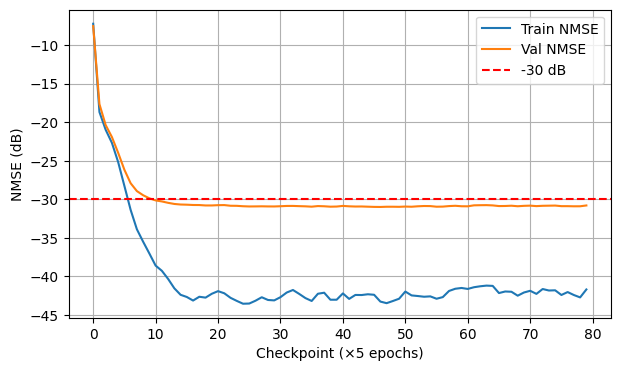

In [7]:

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
def run():

    (trX, trY, trLast,
     vaX, vaY, vaLast,
     teX, teY, teLast,
     feat_dim) = get_csi_loaders(
        "/kaggle/input/datasets/theroyalseal/10kmph-dataset-and-mamba-architecture/csi_data_converted.npy",
        args.window
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"

    half = feat_dim // 2
    split = lambda x: (x[..., :half], x[..., half:])

    # ---------------- Split amplitude / phase ----------------
    trX_amp, trX_phase = split(trX)
    trY_amp, trY_phase = split(trY)
    trL_amp, trL_phase = split(trLast)

    vaX_amp, vaX_phase = split(vaX)
    vaY_amp, vaY_phase = split(vaY)
    vaL_amp, vaL_phase = split(vaLast)

    teX_amp, teX_phase = split(teX)
    teY_amp, teY_phase = split(teY)
    teL_amp, teL_phase = split(teLast)

    # ---------------- Models ----------------
    model_amp = MambaResidual(half, args.hidden, args.layer).to(device)
    model_phase = MambaResidual(half, args.hidden, args.layer).to(device)

    opt = torch.optim.AdamW(
        list(model_amp.parameters()) + list(model_phase.parameters()),
        lr=args.lr,
        weight_decay=args.wd
    )

    train_hist = []
    val_hist = []

    # ====================================================
    # TRAIN LOOP
    # ====================================================
    for epoch in range(args.epochs):

        model_amp.train()
        model_phase.train()

        idx = torch.randperm(len(trX))[:args.batch]

        xa = trX_amp[idx].to(device)
        xp = trX_phase[idx].to(device)

        ya = trY_amp[idx].to(device)
        yp = trY_phase[idx].to(device)

        last_a = trL_amp[idx].to(device)
        last_p = trL_phase[idx].to(device)

        # last snapshot centering
        xa = xa - xa[:, -1:, :]
        xp = xp - xp[:, -1:, :]

        # forward
        dfa, dsa = model_amp(xa)
        dfp, dsp = model_phase(xp)

        wa = torch.softmax(torch.stack([model_amp.alpha, model_amp.beta]), dim=0)
        wp = torch.softmax(torch.stack([model_phase.alpha, model_phase.beta]), dim=0)

        alpha_a, beta_a = wa
        alpha_p, beta_p = wp

        # amplitude prediction
        amp_pred = last_a + alpha_a * dfa + beta_a * dsa

        # phase increment prediction
        phase_delta = alpha_p * dfp + beta_p * dsp
        phase_pred = last_p + phase_delta

        # ---------------- LOSS ----------------
        amp_loss = ((amp_pred - ya) ** 2).mean()

        phase_loss = torch.mean(
            1 - torch.cos(phase_pred - yp)
        )

        phase_smooth = ((phase_pred - last_p) ** 2).mean()

        loss = amp_loss + 0.5 * phase_loss + 0.01 * phase_smooth

        opt.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_amp.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(model_phase.parameters(), 1.0)

        opt.step()

        # ====================================================
        # VALIDATION + TRAIN MONITOR
        # ====================================================
        if epoch % 5 == 0:

            model_amp.eval()
            model_phase.eval()

            with torch.no_grad():

                # ---------- VALIDATION ----------
                xa = vaX_amp[:64].to(device) - vaX_amp[:64, -1:, :].to(device)
                xp = vaX_phase[:64].to(device) - vaX_phase[:64, -1:, :].to(device)

                dfa, dsa = model_amp(xa)
                dfp, dsp = model_phase(xp)

                wa = torch.softmax(torch.stack([model_amp.alpha, model_amp.beta]), dim=0)
                wp = torch.softmax(torch.stack([model_phase.alpha, model_phase.beta]), dim=0)

                aa, ba = wa
                ap, bp = wp

                amp_pred = vaL_amp[:64].to(device) + aa * dfa + ba * dsa
                phase_pred = vaL_phase[:64].to(device) + ap * dfp + bp * dsp

                val_pred = torch.cat([amp_pred, phase_pred], dim=1)
                val_true = torch.cat([vaY_amp[:64], vaY_phase[:64]], dim=1).to(device)

                val_db = nmse_db(val_pred, val_true)
                val_hist.append(val_db.item())

                # ---------- TRAIN MONITOR ----------
                xa = trX_amp[:64].to(device) - trX_amp[:64, -1:, :].to(device)
                xp = trX_phase[:64].to(device) - trX_phase[:64, -1:, :].to(device)

                dfa, dsa = model_amp(xa)
                dfp, dsp = model_phase(xp)

                amp_pred = trL_amp[:64].to(device) + aa * dfa + ba * dsa
                phase_pred = trL_phase[:64].to(device) + ap * dfp + bp * dsp

                train_pred = torch.cat([amp_pred, phase_pred], dim=1)
                train_true = torch.cat([trY_amp[:64], trY_phase[:64]], dim=1).to(device)

                train_db = nmse_db(train_pred, train_true)
                train_hist.append(train_db.item())

                print(f"Epoch {epoch:03d} | Train {train_db:.2f} dB | Val {val_db:.2f} dB")

    # ====================================================
    # TEST
    # ====================================================
    model_amp.eval()
    model_phase.eval()

    with torch.no_grad():

        xa = teX_amp.to(device) - teX_amp[:, -1:, :].to(device)
        xp = teX_phase.to(device) - teX_phase[:, -1:, :].to(device)

        dfa, dsa = model_amp(xa)
        dfp, dsp = model_phase(xp)

        wa = torch.softmax(torch.stack([model_amp.alpha, model_amp.beta]), dim=0)
        wp = torch.softmax(torch.stack([model_phase.alpha, model_phase.beta]), dim=0)

        aa, ba = wa
        ap, bp = wp

        amp_pred = teL_amp.to(device) + aa * dfa + ba * dsa
        phase_pred = teL_phase.to(device) + ap * dfp + bp * dsp

        test_pred = torch.cat([amp_pred, phase_pred], dim=1)
        test_true = torch.cat([teY_amp, teY_phase], dim=1).to(device)

        test_db = nmse_db(test_pred, test_true)

    print("\nFINAL TEST NMSE:", test_db.item(), "dB")
    # ====================================================
    # FLOPs & PARAMETERS (CLEAN)
    # ====================================================
    import logging
    from fvcore.nn import FlopCountAnalysis

    logging.getLogger("fvcore").setLevel(logging.ERROR)
    logging.getLogger("fvcore.nn.jit_analysis").setLevel(logging.ERROR)

    dummy = torch.randn(1, args.window, half).to(device)

    flops = FlopCountAnalysis(model_amp, dummy).total() + \
            FlopCountAnalysis(model_phase, dummy).total()
    
    params = sum(p.numel() for p in model_amp.parameters()) + \
             sum(p.numel() for p in model_phase.parameters())

    print("\n=== MODEL COMPLEXITY SUMMARY ===")
    print(f"Total FLOPs  : {flops / 1e9:.3f} GFLOPs")
    print(f"Total Params : {params / 1e6:.2f} Million")

    # ====================================================
    # PLOT
    # ====================================================
    plt.figure(figsize=(7,4))
    plt.plot(train_hist, label="Train NMSE")
    plt.plot(val_hist, label="Val NMSE")
    plt.axhline(-30, color="r", linestyle="--", label="-30 dB")
    plt.xlabel("Checkpoint (×5 epochs)")
    plt.ylabel("NMSE (dB)")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    run() 